#Downloads + Installations

In [1]:
!wget "https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1" -O ravdess.zip
!unzip ravdess.zip -d data
!rm ravdess.zip

--2026-03-06 21:43:26--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘ravdess.zip’

ravdess.zip         100%[===================>] 198.81M  19.7MB/s    in 12s     

2026-03-06 21:43:39 (17.3 MB/s) - ‘ravdess.zip’ saved [208468073/208468073]

Archive:  ravdess.zip
   creating: data/Actor_01/
  inflating: data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: data/Acto

In [2]:
pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 34.9 MB/s eta 0:00:00


#Imports

In [3]:
import os, glob, re
import numpy as np
import pandas as pd
from tqdm import tqdm

import opensmile

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


#OpenSmile Objects

In [4]:
# LLDs
smile_lld = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors
)

# Functionals
smile_func = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)


#Label parsing utilities

In [5]:
EMOTION_MAP = {
    1: "neutral",
    2: "calm",
    3: "happy",
    4: "sad",
    5: "angry",
    6: "fearful",
    7: "disgust",
    8: "surprised",
}

def parse_ravdess_label(filepath: str):
    """
    Returns emotion_name, emotion_id from a RAVDESS filename.
    """
    base = os.path.basename(filepath)
    m = re.match(r"(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)-(\d+)\.wav$", base)
    if not m:
        return None, None
    emo_id = int(m.group(3))
    return EMOTION_MAP.get(emo_id, None), emo_id

# Collect all wav files
wav_files = sorted(glob.glob("data/Actor_*/**/*.wav", recursive=True))

print("WAV files found:", len(wav_files))
print("Example:", wav_files[0] if wav_files else "None")

WAV files found: 1440
Example: data/Actor_01/03-01-01-01-01-01-01.wav


#Extract FUNCTIONALS for all files

In [6]:
func_rows = []
meta_rows = []

for fp in tqdm(wav_files):
    emo_name, emo_id = parse_ravdess_label(fp)
    if emo_name is None:
        continue

    feat = smile_func.process_file(fp)         # pandas DataFrame (1 row)
    feat = feat.reset_index(drop=True)         # ensure single row index
    feat["file"] = fp
    feat["emotion"] = emo_name
    feat["emotion_id"] = emo_id

    func_rows.append(feat)

func_df = pd.concat(func_rows, ignore_index=True)
print("Functionals shape:", func_df.shape)
func_df.head()

100%|██████████| 1440/1440 [05:39<00:00,  4.24it/s]

Functionals shape: (1440, 91)


,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,file,emotion,emotion_id
0,24.263884,0.104171,21.653511,23.907379,27.101028,5.447517,104.436584,113.437210,31.389978,8.258454,...,2.127660,0.925926,0.336667,0.226912,0.540000,0.480260,-47.939644,data/Actor_01/03-01-01-01-01-01-01.wav,neutral,1
1,25.167889,0.103561,23.178247,25.003677,27.699860,4.521612,56.695114,18.043581,9.703053,9.479507,...,2.409639,1.223242,0.257500,0.089826,0.535000,0.485206,-47.342331,data/Actor_01/03-01-01-01-01-02-01.wav,neutral,1
2,24.186604,0.103495,22.353912,23.728384,27.093287,4.739374,209.152557,255.810776,13.067563,11.153259,...,2.153846,0.630915,0.545000,0.175000,0.676667,0.414836,-45.849762,data/Actor_01/03-01-01-01-02-01-01.wav,neutral,1
3,24.268761,0.096042,22.443832,24.478970,26.744179,4.300346,159.005051,128.233871,31.331654,10.120683,...,2.222222,0.977199,0.333333,0.267374,0.500000,0.445702,-46.193146,data/Actor_01/03-01-01-01-02-02-01.wav,neutral,1
4,24.898132,0.117897,22.419266,24.678062,28.138033,5.718767,214.876068,234.977676,32.979195,25.259748,...,2.840909,1.440922,0.182000,0.116172,0.408333,0.441717,-50.563885,data/Actor_01/03-01-02-01-01-01-01.wav,calm,2


In [7]:
# Save functionals to CSV
os.makedirs("outputs", exist_ok=True)
func_df.to_csv("outputs/egemaps_functionals.csv", index=False)

#Extract LLDs for all files

In [8]:
lld_dict = {}
lld_meta = []

for fp in tqdm(wav_files):
    emo_name, emo_id = parse_ravdess_label(fp)
    if emo_name is None:
        continue

    lld = smile_lld.process_file(fp)  # DataFrame indexed by time
    lld_dict[fp] = lld

    lld_meta.append({
        "file": fp,
        "emotion": emo_name,
        "emotion_id": emo_id,
        "n_frames": len(lld),
        "n_features": lld.shape[1]
    })

lld_meta_df = pd.DataFrame(lld_meta)
print("LLD files extracted:", len(lld_dict))
lld_meta_df.describe(include="all")

100%|██████████| 1440/1440 [06:09<00:00,  3.89it/s]

LLD files extracted: 1440


,file,emotion,emotion_id,n_frames,n_features
count,1440,1440,1440.000000,1440.000000,1440.0
unique,1440,8,NaN,NaN,NaN
top,data/Actor_24/03-01-06-02-02-02-24.wav,calm,NaN,NaN,NaN
freq,1,192,NaN,NaN,NaN
mean,NaN,NaN,4.733333,365.657639,25.0
std,NaN,NaN,2.175356,33.695198,0.0
min,NaN,NaN,1.000000,289.000000,25.0
25%,NaN,NaN,3.000000,343.000000,25.0
50%,NaN,NaN,5.000000,363.000000,25.0
75%,NaN,NaN,7.000000,383.000000,25.0


In [9]:
# save LLD meta
lld_meta_df.to_csv("outputs/egemaps_lld_meta.csv", index=False)

#ML Classification with Functionals

In [10]:
# Features = all OpenSmile columns except metadata
drop_cols = ["file", "emotion", "emotion_id"]
feature_cols = [c for c in func_df.columns if c not in drop_cols]

X = func_df[feature_cols].values
y_text = func_df["emotion"].values

le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = list(le.classes_)

print("X:", X.shape, "y:", y.shape)
print("Classes:", class_names)

X: (1440, 88) y: (1440,)
Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [11]:
# 5-fold CV training + aggregated confusion matrix
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=5.0, gamma="scale"))  # simple + strong baseline
])

fold_accuracies = []
cm_total = np.zeros((len(class_names), len(class_names)), dtype=int)

all_true = []
all_pred = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    fold_accuracies.append(acc)

    cm = confusion_matrix(y_test, pred, labels=np.arange(len(class_names)))
    cm_total += cm

    all_true.extend(y_test.tolist())
    all_pred.extend(pred.tolist())

    print(f"Fold {fold} accuracy: {acc:.4f}")

print("\nMean accuracy:", np.mean(fold_accuracies), "±", np.std(fold_accuracies))

Fold 1 accuracy: 0.6667
Fold 2 accuracy: 0.6667
Fold 3 accuracy: 0.6736
Fold 4 accuracy: 0.6667
Fold 5 accuracy: 0.6493

Mean accuracy: 0.6645833333333334 ± 0.008098544298396246


#Results Visualization

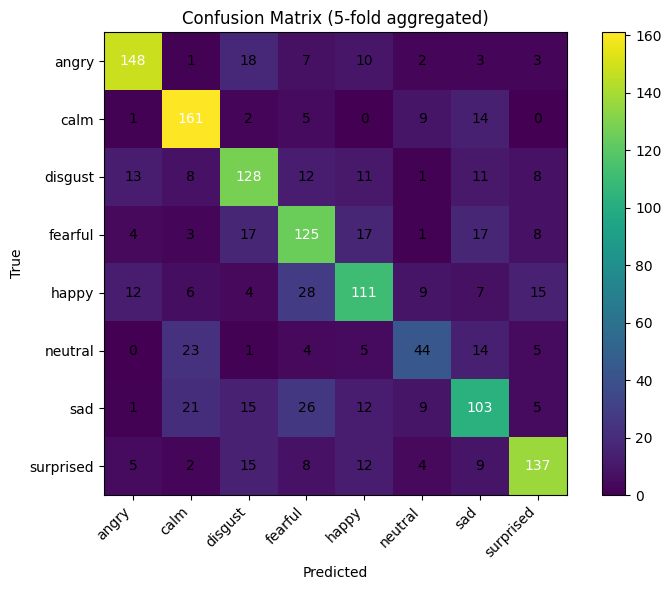

In [12]:
# Confusion matrix plot (aggregated over folds)

def plot_confusion_matrix(cm, labels, title="Confusion Matrix (5-fold aggregated)"):
    fig = plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    thresh = cm.max() * 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_total, class_names)

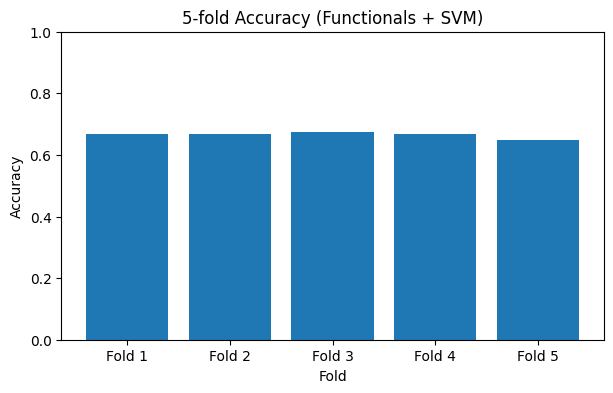

Mean accuracy: 0.6645833333333334


In [13]:
# Accuracy per fold bar plot

plt.figure(figsize=(7,4))
plt.bar(np.arange(1, 6), fold_accuracies)
plt.ylim(0, 1)
plt.xticks(np.arange(1, 6), [f"Fold {i}" for i in range(1,6)])
plt.title("5-fold Accuracy (Functionals + SVM)")
plt.ylabel("Accuracy")
plt.xlabel("Fold")
plt.show()

print("Mean accuracy:", np.mean(fold_accuracies))

In [14]:
# Classification report (overall, pooled predictions)

print(classification_report(all_true, all_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

       angry     0.8043    0.7708    0.7872       192
        calm     0.7156    0.8385    0.7722       192
     disgust     0.6400    0.6667    0.6531       192
     fearful     0.5814    0.6510    0.6143       192
       happy     0.6236    0.5781    0.6000       192
     neutral     0.5570    0.4583    0.5029        96
         sad     0.5787    0.5365    0.5568       192
   surprised     0.7569    0.7135    0.7346       192

    accuracy                         0.6646      1440
   macro avg     0.6572    0.6517    0.6526      1440
weighted avg     0.6639    0.6646    0.6626      1440



#Optional Task - LLD + Time-Dependent Model (GRU)

In [15]:
# Build padded LLD tensor (N, T, F)
# To keep runtime reasonable in Colab, I’ll cap to MAX_LEN=250 frames.
MAX_LEN = 250  # truncate/pad length

# Get consistent feature columns
sample_fp = next(iter(lld_dict.keys()))
lld_feature_cols = list(lld_dict[sample_fp].columns)
F = len(lld_feature_cols)

X_seq = []
lengths = []
y_seq_text = []
files_seq = []

for fp, lld in lld_dict.items():
    emo_name, emo_id = parse_ravdess_label(fp)
    if emo_name is None:
        continue

    arr = lld[lld_feature_cols].values.astype(np.float32)
    L = min(len(arr), MAX_LEN)     # true length after truncation
    lengths.append(L)

    if len(arr) >= MAX_LEN:
        arr = arr[:MAX_LEN]
    else:
        pad = np.zeros((MAX_LEN - len(arr), F), dtype=np.float32)
        arr = np.vstack([arr, pad])

    X_seq.append(arr)
    y_seq_text.append(emo_name)
    files_seq.append(fp)

X_seq = np.stack(X_seq, axis=0)  # (N,T,F)
lengths = np.array(lengths, dtype=np.int64)
y_seq = le.transform(np.array(y_seq_text)).astype(np.int64)

print("X_seq:", X_seq.shape, "lengths:", lengths.shape, "y_seq:", y_seq.shape)

X_seq: (1440, 250, 25) lengths: (1440,) y_seq: (1440,)


In [16]:
# GRU  Dataset + Model

class SequenceDataset(Dataset):
    def __init__(self, X, lengths, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.lengths[idx], self.y[idx]

class GRUClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1, dropout=0.2, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x, lengths):
        # x: (B,T,F), lengths: (B,)
        # pack for variable lengths (masking padded frames)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, h_n = self.gru(packed)

        # h_n: (num_layers * num_directions, B, hidden_dim)
        if self.bidirectional:
            # last layer has 2 directions: forward and backward
            # take last layer forward/backward and concat
            forward = h_n[-2]  # (B, hidden_dim)
            backward = h_n[-1] # (B, hidden_dim)
            h = torch.cat([forward, backward], dim=1)
        else:
            h = h_n[-1]  # (B, hidden_dim)

        h = self.dropout(h)
        logits = self.fc(h)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [17]:
# Per-fold standardization

def standardize_train_test_seq(Xtr, Xte, eps=1e-8):
    # X: (N,T,F)
    mean = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    std = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + eps
    Xtr_n = (Xtr - mean) / std
    Xte_n = (Xte - mean) / std
    return Xtr_n, Xte_n

In [18]:
# Train/Eval + Early stopping

def run_one_epoch(model, loader, optimizer=None, criterion=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for xb, lb, yb in loader:
            xb, lb, yb = xb.to(device), lb.to(device), yb.to(device)

            logits = model(xb, lb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            pred = torch.argmax(logits, dim=1)
            all_true.extend(yb.detach().cpu().numpy().tolist())
            all_pred.extend(pred.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_pred)
    return avg_loss, acc, np.array(all_true), np.array(all_pred)

class EarlyStopper:
    def __init__(self, patience=3, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.bad_epochs = 0
        self.best_state = None

    def step(self, metric, model):
        improved = False
        if self.best is None:
            improved = True
        else:
            improved = metric > self.best if self.mode == "max" else metric < self.best

        if improved:
            self.best = metric
            self.bad_epochs = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False  # don't stop
        else:
            self.bad_epochs += 1
            return self.bad_epochs >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [19]:
# 5-fold CV

def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    thresh = cm.max() * 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gru_fold_acc = []
cm_total_gru = np.zeros((len(class_names), len(class_names)), dtype=int)
all_true_gru, all_pred_gru = [], []

# hyperparams (simple, safe defaults)
HIDDEN = 64
BIDIR = False
LR = 1e-3
BATCH = 32
EPOCHS = 20
PATIENCE = 3

for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq, y_seq), start=1):
    Xtr, Xte = X_seq[train_idx], X_seq[test_idx]
    Ltr, Lte = lengths[train_idx], lengths[test_idx]
    ytr, yte = y_seq[train_idx], y_seq[test_idx]

    # standardize by train fold statistics only
    Xtr, Xte = standardize_train_test_seq(Xtr, Xte)

    # simple validation split from training fold (stratified-ish via shuffle)
    # We'll take last 15% as val after shuffling indices
    rng = np.random.default_rng(42 + fold)
    perm = rng.permutation(len(Xtr))
    Xtr, Ltr, ytr = Xtr[perm], Ltr[perm], ytr[perm]

    n_val = max(1, int(0.15 * len(Xtr)))
    Xval, Lval, yval = Xtr[:n_val], Ltr[:n_val], ytr[:n_val]
    Xtrain, Ltrain, ytrain = Xtr[n_val:], Ltr[n_val:], ytr[n_val:]

    train_ds = SequenceDataset(Xtrain, Ltrain, ytrain)
    val_ds   = SequenceDataset(Xval,   Lval,   yval)
    test_ds  = SequenceDataset(Xte,    Lte,    yte)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, drop_last=False)

    model = GRUClassifier(
        input_dim=F,
        hidden_dim=HIDDEN,
        num_classes=len(class_names),
        num_layers=1,
        dropout=0.2,
        bidirectional=BIDIR
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    stopper = EarlyStopper(patience=PATIENCE, mode="max")

    # Train
    for epoch in tqdm(range(1, EPOCHS + 1)):
        tr_loss, tr_acc, _, _ = run_one_epoch(model, train_loader, optimizer=optimizer, criterion=criterion)
        va_loss, va_acc, _, _ = run_one_epoch(model, val_loader, optimizer=None, criterion=criterion)

        stop = stopper.step(va_acc, model)
        # Uncomment if you want logs:
        # print(f"Fold {fold} | Epoch {epoch:02d} | train acc {tr_acc:.3f} | val acc {va_acc:.3f}")

        if stop:
            break

    stopper.restore_best(model)

    # Test
    te_loss, te_acc, y_true, y_pred = run_one_epoch(model, test_loader, optimizer=None, criterion=criterion)
    gru_fold_acc.append(te_acc)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_total_gru += cm

    all_true_gru.extend(y_true.tolist())
    all_pred_gru.extend(y_pred.tolist())

    print(f"Fold {fold} GRU(Pytorch) accuracy: {te_acc:.4f}")

print("\nGRU(Pytorch) Mean accuracy:", float(np.mean(gru_fold_acc)), "±", float(np.std(gru_fold_acc)))

 60%|██████    | 12/20 [00:05<00:03,  2.02it/s]


Fold 1 GRU(Pytorch) accuracy: 0.4375


 55%|█████▌    | 11/20 [00:03<00:03,  2.86it/s]


Fold 2 GRU(Pytorch) accuracy: 0.4271


100%|██████████| 20/20 [00:06<00:00,  2.88it/s]


Fold 3 GRU(Pytorch) accuracy: 0.4931


 75%|███████▌  | 15/20 [00:05<00:01,  2.97it/s]


Fold 4 GRU(Pytorch) accuracy: 0.5035


 60%|██████    | 12/20 [00:04<00:02,  2.90it/s]

Fold 5 GRU(Pytorch) accuracy: 0.4097

GRU(Pytorch) Mean accuracy: 0.4541666666666667 ± 0.037228958760222815


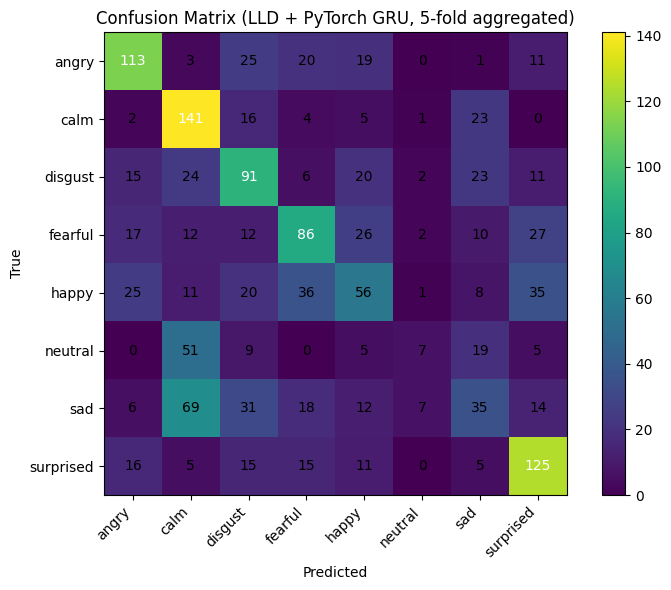

              precision    recall  f1-score   support

       angry     0.5825    0.5885    0.5855       192
        calm     0.4462    0.7344    0.5551       192
     disgust     0.4155    0.4740    0.4428       192
     fearful     0.4649    0.4479    0.4562       192
       happy     0.3636    0.2917    0.3237       192
     neutral     0.3500    0.0729    0.1207        96
         sad     0.2823    0.1823    0.2215       192
   surprised     0.5482    0.6510    0.5952       192

    accuracy                         0.4542      1440
   macro avg     0.4317    0.4303    0.4126      1440
weighted avg     0.4371    0.4542    0.4321      1440



In [20]:
# GRU confusion matrix + report

plot_confusion_matrix(cm_total_gru, class_names, title="Confusion Matrix (LLD + PyTorch GRU, 5-fold aggregated)")
print(classification_report(all_true_gru, all_pred_gru, target_names=class_names, digits=4))